In [1]:
import os
from spectral.io import envi
import numpy as np
from glob import glob
import matplotlib.pyplot as plt

import sys
sys.path.append('/store/carroll/repos/chess-isofit/')
from utilities import viz_rfl_subset

from isoplots import plots
import xarray as xr

import rasterio
from rasterio.transform import array_bounds
from rasterio.plot import show
from rasterio.plot import plotting_extent

%matplotlib widget

os.chdir('/store/carroll/col/data/')

In [46]:
fids = ['NIS01_20250614_182048_ALMO_DP1_L046-1',
        'NIS01_20250626_160740_CRBU_DP1_L012-1',
        'NIS01_20250702_155419_CRBU_DP1_L061-1',
        'NIS01_20250712_145512_UPTA_DP1_L034-1']

fid = fids[0]

In [3]:
out_figs = '/store/carroll/col/figs/'

wl = np.loadtxt('wavelengths_neon.txt')[:,1]*1000
wl_nan = np.loadtxt('wl_nan.txt')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0052388166..1.0].


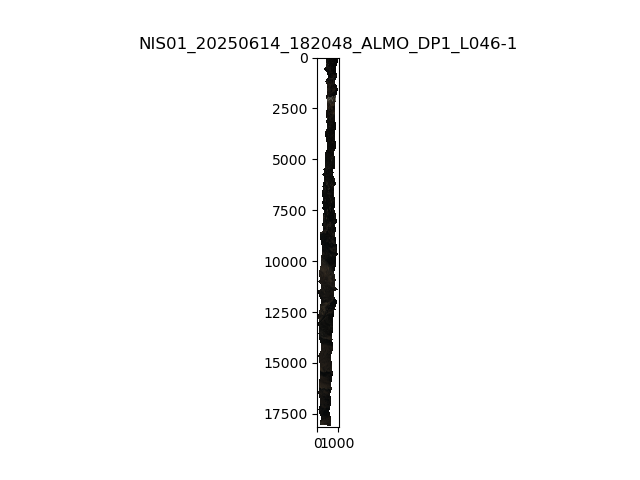

In [47]:
# check full rfl rgb for test

working_dir = f'2025/deploy_6c_20260120/{fid}'
fp = glob(os.path.join(working_dir, 'output', '*_rfl.hdr'))[0]
rgb = envi.open(fp).open_memmap()[:,:,np.array([60,40,30])].copy()

rgb[rgb==0] = np.nan
rgb[rgb>1] = 1

fig = plt.figure()
plt.imshow(rgb / np.nanmax(rgb, axis=(0, 1)))
plt.title(fid)

plt.show()

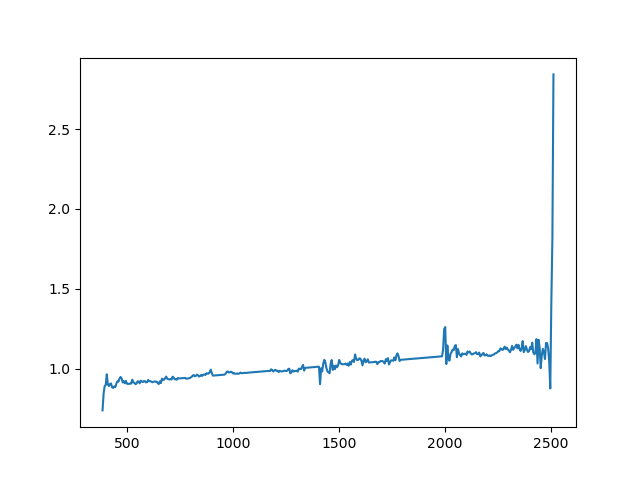

In [5]:
# load rccs
rccs = np.loadtxt('2025/rccs/rcc_snodgrass_mean_6c_processed.txt')
fig = plt.figure()
plt.plot(wl, rccs)
plt.show()

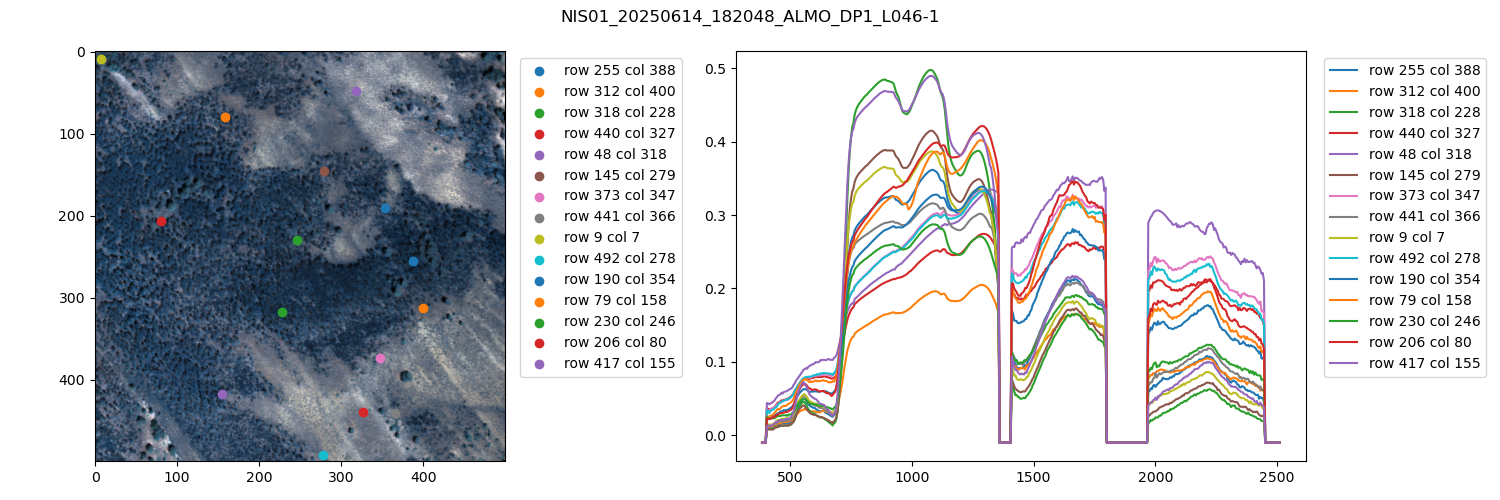

In [53]:
# plot some spectra

# fid =test_fid
working_dir = os.path.join('2025/deploy_6c_20260120', fid)

size = 500
row1 = 9000; col1 = 400

viz_rfl_subset(flight=fid, working_dir=working_dir, row1=row1, col1=col1, size=size, n_sample=15, wl=wl)

# plt.savefig(os.path.join(out_figs, f'rfl_{fid}_row{row1}_col{col1}.png'), dpi=300)